# TINYViT assesment:

Multiple ViT profiles were made in `/config/vit_configs.json`, we trained them in notebook `3.5`, now we evaluate all of those configurations over the unseen validationdata (the 10% part that was taken away in notebook `3.1`). 

The best performing configuration out of this assesment gets trained on the full dataset, without making further changes to the configuration. There is a certain methodological risk involved to go from four to thirty classes. But this effect was hardly seen on using TINYCNN vs the full CNN training (`3.2` vs `3.3`). So I'm fairly optimistic

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

import sys
sys.path.append('../../utils')
from vit_helpers import ImageDataGeneratorFromDF, PatchEncoder, Patches, get_vit_configurations

from configloader import Configloader

import cnn_helpers
import implot


2025-04-19 18:02:10.022729: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
PHASE = 'brand phase'
CROP = True
BATCH_SIZE = 128

In [3]:
cnn_helpers.system_override()
cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-04-19 18:02:12.592345: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 18:02:14.912336: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 18:02:14.912413: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


'GPU'

In [4]:
config = Configloader()

vit_variants = get_vit_configurations(
    os.path.join(
        config.get('directories', 'root_dir'), 
        config.get('settings', 'vit_configurations')
    )
)

In [5]:

basedir = config.get('settings', 'image_directory')
csv_data_dir = config.get('dir_augmentations', 'csv_dir')



In [6]:
csv_dir = os.path.join(basedir, csv_data_dir, PHASE)  #where the train/test/valid split in step 3.1 was done.
csv_dir

'/home/frederic/Documents/automotive_image_data/CSV-data/brand phase'

In [7]:
validation_df_path = os.path.join(csv_dir, 'validationdata_brandphase.csv')
validation_df_full = pd.read_csv(validation_df_path)

In [8]:
validation_df_full = cnn_helpers.shuffle_df(validation_df_full)
validation_df_full

,image_id,model_label,model_score,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,brand,abs_path
0,7313487,rearleft,1.000000,61,121,681,502,7313487,0.999159,1.000000,0.995997,0.997878,peugeot,/home/frederic/Documents/automotive_image_data...
1,8077797,left,0.817493,30,140,718,466,8077797,0.974623,1.000000,0.998503,0.994214,mini,/home/frederic/Documents/automotive_image_data...
2,8290754,frontleft,1.000000,4,13,742,540,8290754,0.914299,0.999969,0.976084,0.994075,toyota,/home/frederic/Documents/automotive_image_data...
3,15785,left,1.000000,23,39,727,330,15785,0.959778,0.999994,0.980848,0.855370,fiat,/home/frederic/Documents/automotive_image_data...
4,10347376,left,1.000000,13,83,730,361,10347376,0.997349,0.999980,0.957996,0.997362,land-rover,/home/frederic/Documents/automotive_image_data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399056,2460929,rearright,1.000000,37,88,652,485,2460929,0.982186,0.860984,0.302600,0.906301,skoda,/home/frederic/Documents/automotive_image_data...
399057,3115898,right,1.000000,21,144,713,422,3115898,0.991323,0.999649,0.984002,0.981180,audi,/home/frederic/Documents/automotive_image_data...
399058,5046249,left,1.000000,40,171,677,410,5046249,0.952996,0.997813,0.420793,0.752226,ford,/home/frederic/Documents/automotive_image_data...
399059,13691253,rearleft,0.816780,62,21,725,409,13691253,0.343035,0.999897,0.971060,0.935372,nissan,/home/frederic/Documents/automotive_image_data...


In [9]:
model_read_dir = os.path.join(config.get('directories', 'root_dir'),
                              config.get('directories', 'vit_dir'))


In [10]:
# Training was done on the front angle only, do'nt bother 

#TODO implement angle stuff.
def evaluate_vit(configs):
    results = {}
    actuals = {}
    angles = ['front']

    # Run evaluation loop on all ids in the dict
    for vit_id, variant in configs.items():
        patch_size = variant["PATCH_SIZE"]
        shape = variant["SHAPE"]
        PATCHES = (shape // patch_size) ** 2
        mode = variant['TINY'] == 'true'
        print(f"Evaluating ViT: {vit_id} with PATCH_SIZE={patch_size}, PATCHES={PATCHES}, Tinymode={mode}")

        if mode:
            brands = ['ford', 'opel', 'bmw', 'renault']
            validation_df = validation_df_full[validation_df_full['brand'].isin(brands)].copy()

        else:
            validation_df = validation_df_full.copy()


        brands = validation_df.brand.unique()
        label_encoder = LabelEncoder()
        label_encoder.fit(brands)
        validation_df['y_encoded'] = label_encoder.transform(validation_df['brand'])

        for angle in angles:
            name = f'{vit_id}-model_cropped={CROP}_angle={angle}.keras'
            model_path = os.path.join(model_read_dir, name)
            if not os.path.exists(model_path):
                print(f"Model {name} not found, skipping.")
                continue

            print(f"Loading model {name}...")
            model = keras.models.load_model(model_path,
                                            custom_objects={"Patches": Patches,
                                                            "PatchEncoder": PatchEncoder})

            view_by_angle_test = validation_df.query('model_label==@angle').reset_index()
            generator = ImageDataGeneratorFromDF(
                df=view_by_angle_test,
                image_column='abs_path',
                label_column='y_encoded',
                batch_size=BATCH_SIZE,
                target_size=(shape, shape),
                shuffle=False,
                apply_crop=CROP
            )

            predictions = []
            #annoyin caveat of Keras, it requires all batches to be of equal length; 
            # this is a way around the issue without the risk of accidentally padding
            # the final batch with a underrepresented test class. (adding 3 entries of a 
            # class that only occurs 4 times naturally)
            for x_batch, _ in generator:
                if len(x_batch)  == 0:
                    break
                batch_preds = model.predict_on_batch(x_batch)
                predictions.extend(batch_preds)
            results[vit_id] = predictions
            actuals[vit_id] = {
                'data': view_by_angle_test['y_encoded'],
                'encoder' : label_encoder
            }
    return [results, actuals]

In [11]:
vit_fulldataset_selection = {k:v for k,v in vit_variants.items() if 'max' in k}
all_vit30_results, all_vit30_actuals = evaluate_vit(vit_fulldataset_selection)


Evaluating ViT: ViT17_max4 with PATCH_SIZE=28, PATCHES=64, Tinymode=False
Loading model ViT17_max4-model_cropped=True_angle=front.keras...


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
2025-04-19 18:02:15.773064: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 18:02:15.773188: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-19 18:02:15.773238: I external/local_xla/xla/stream_executor/rocm/rocm_execut

Evaluating ViT: ViT18_max4 with PATCH_SIZE=28, PATCHES=64, Tinymode=False
Loading model ViT18_max4-model_cropped=True_angle=front.keras...


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Evaluating ViT: ViT19_max4 with PATCH_SIZE=28, PATCHES=64, Tinymode=False
Loading model ViT19_max4-model_cropped=True_angle=front.keras...


...

/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Evaluating ViT: ViT24_max4 with PATCH_SIZE=25, PATCHES=81, Tinymode=False
Loading model ViT24_max4-model_cropped=True_angle=front.keras...


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Evaluating ViT: ViT25_max4 with PATCH_SIZE=22, PATCHES=100, Tinymode=False
Loading model ViT25_max4-model_cropped=True_angle=front.keras...


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


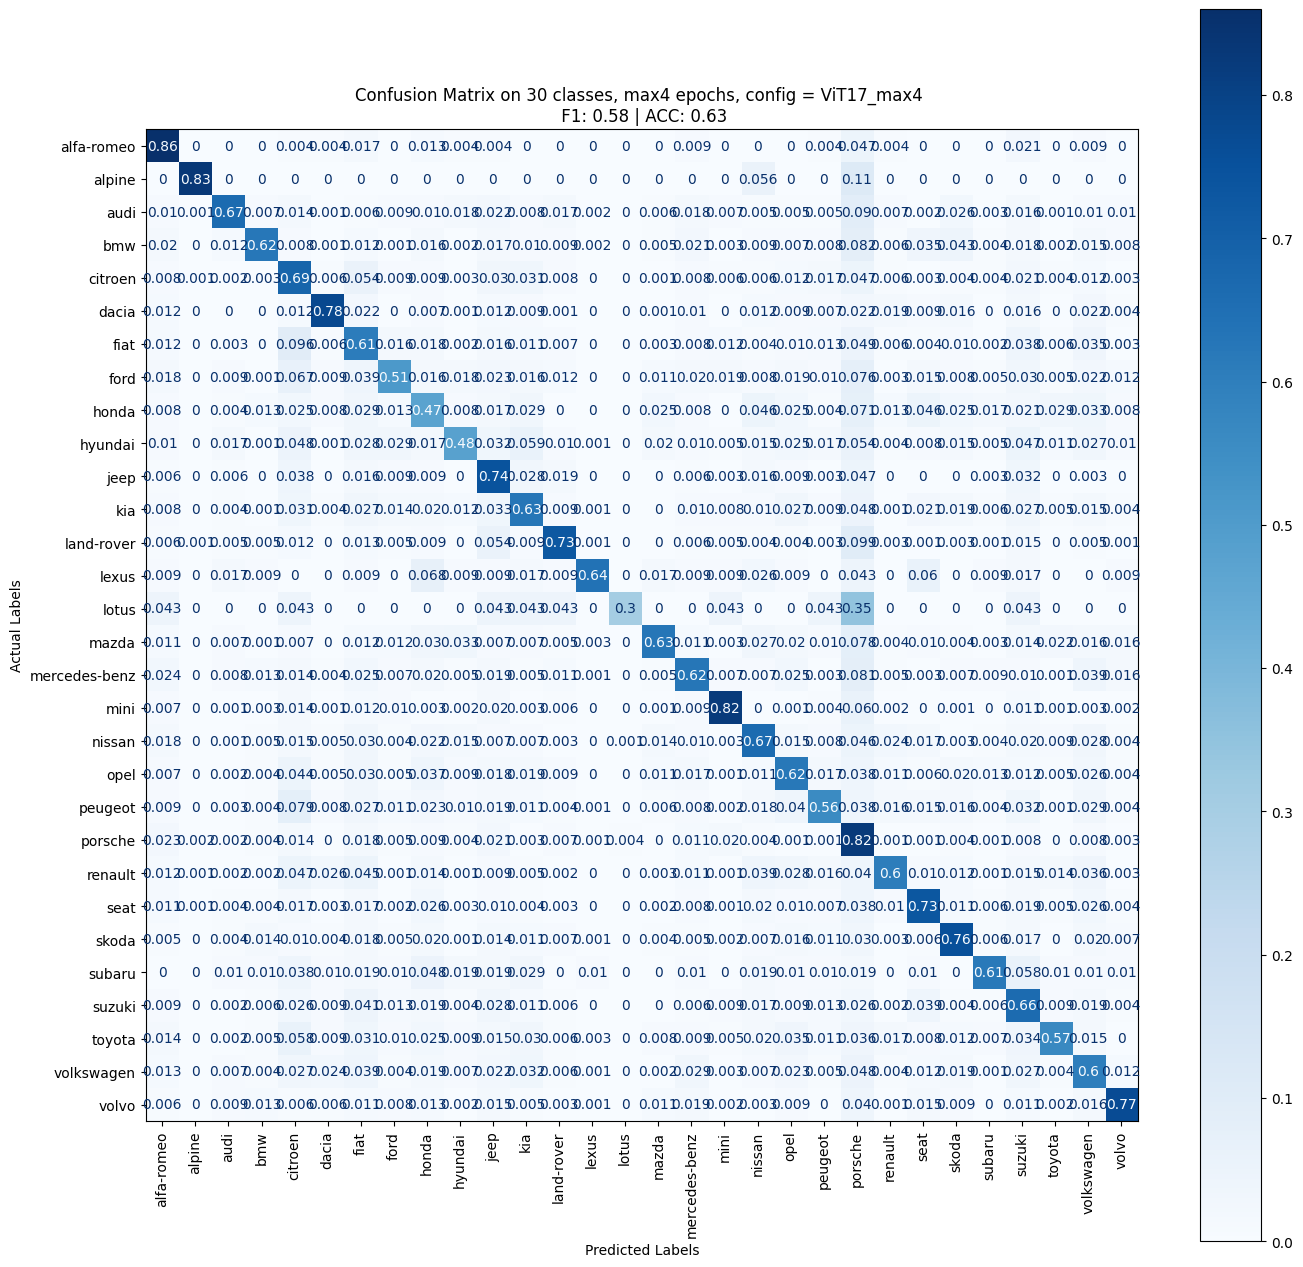

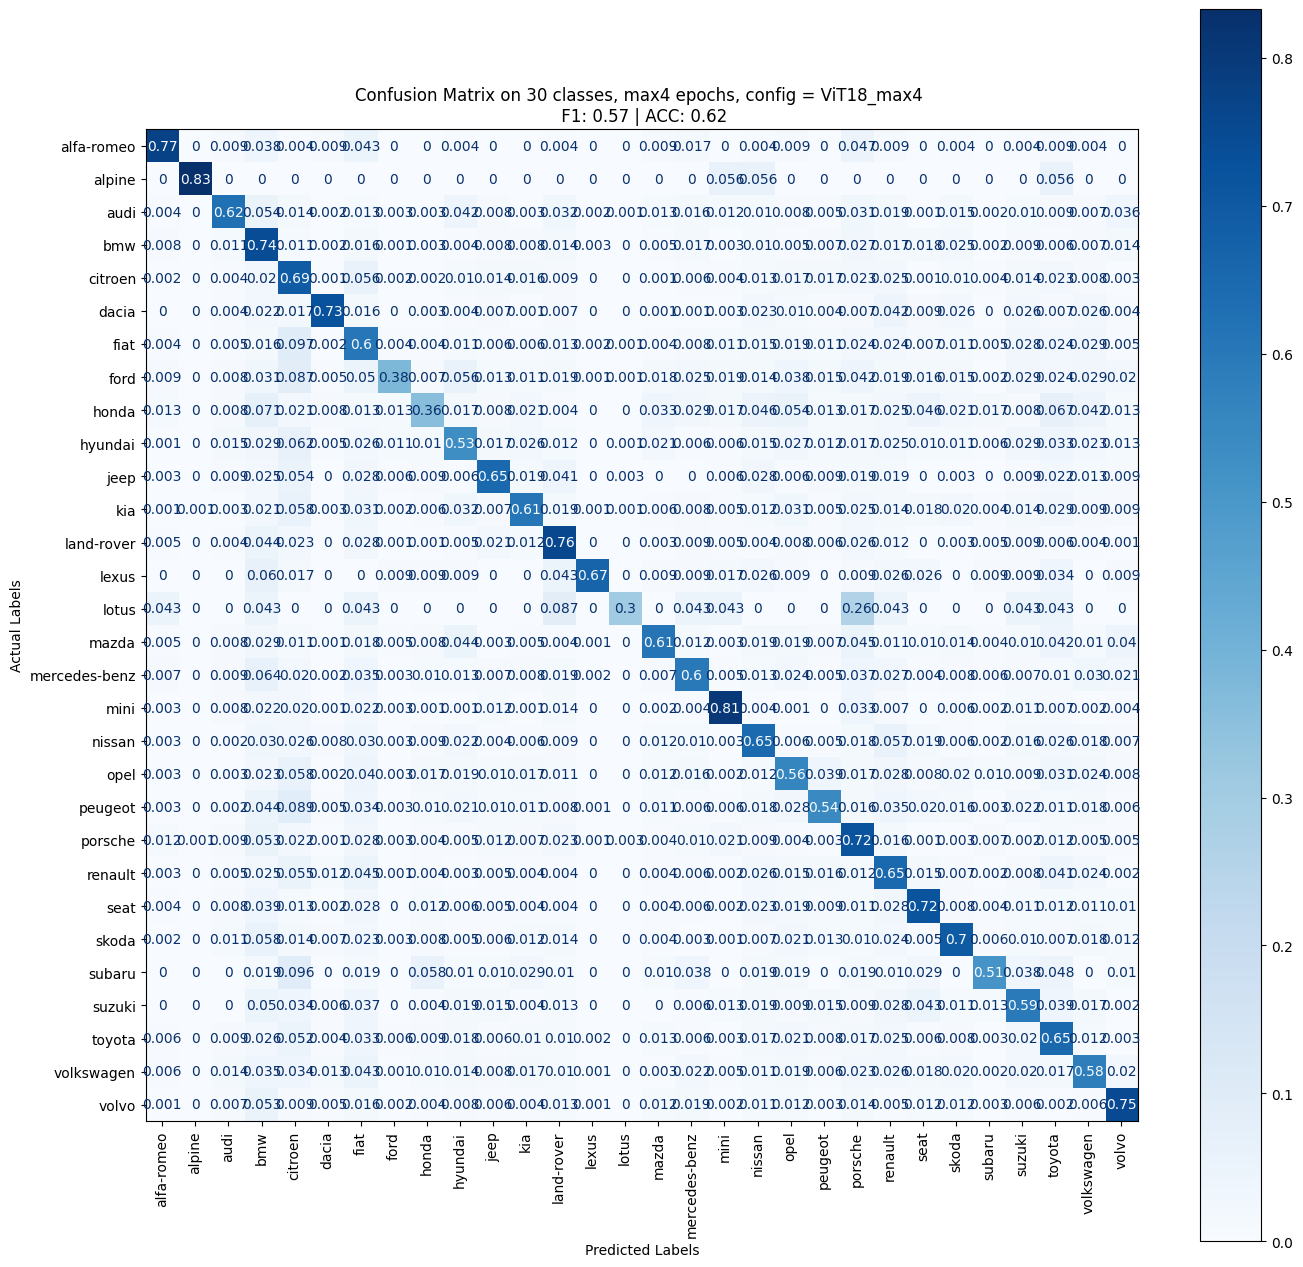

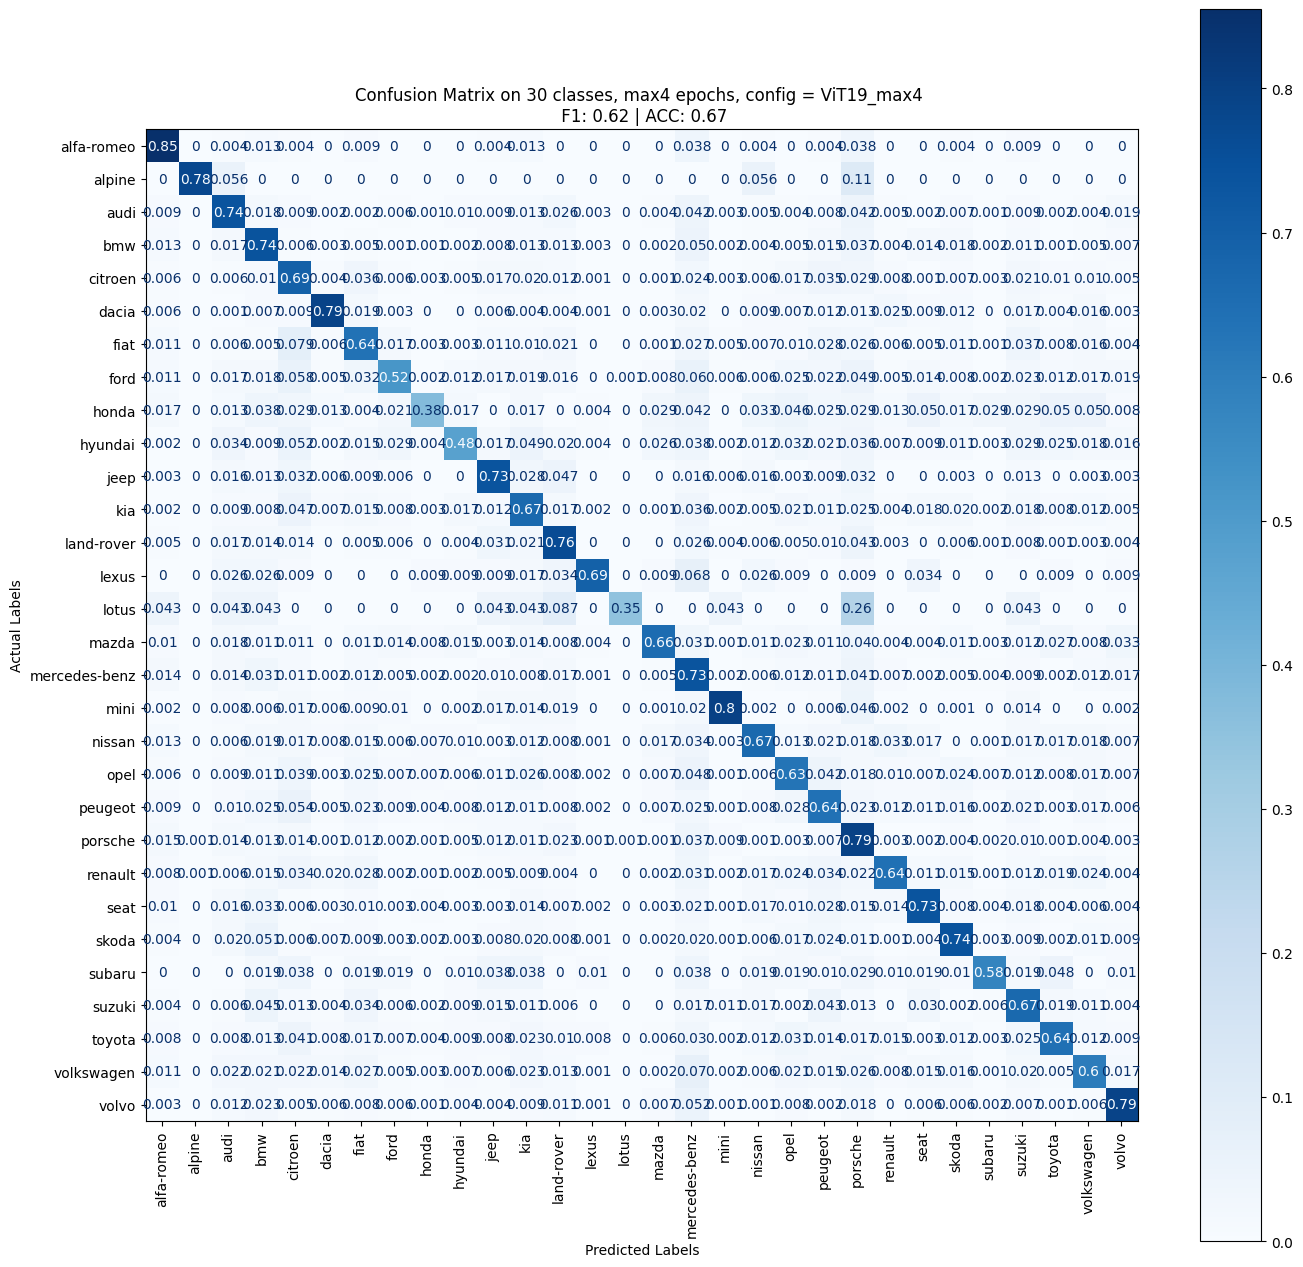

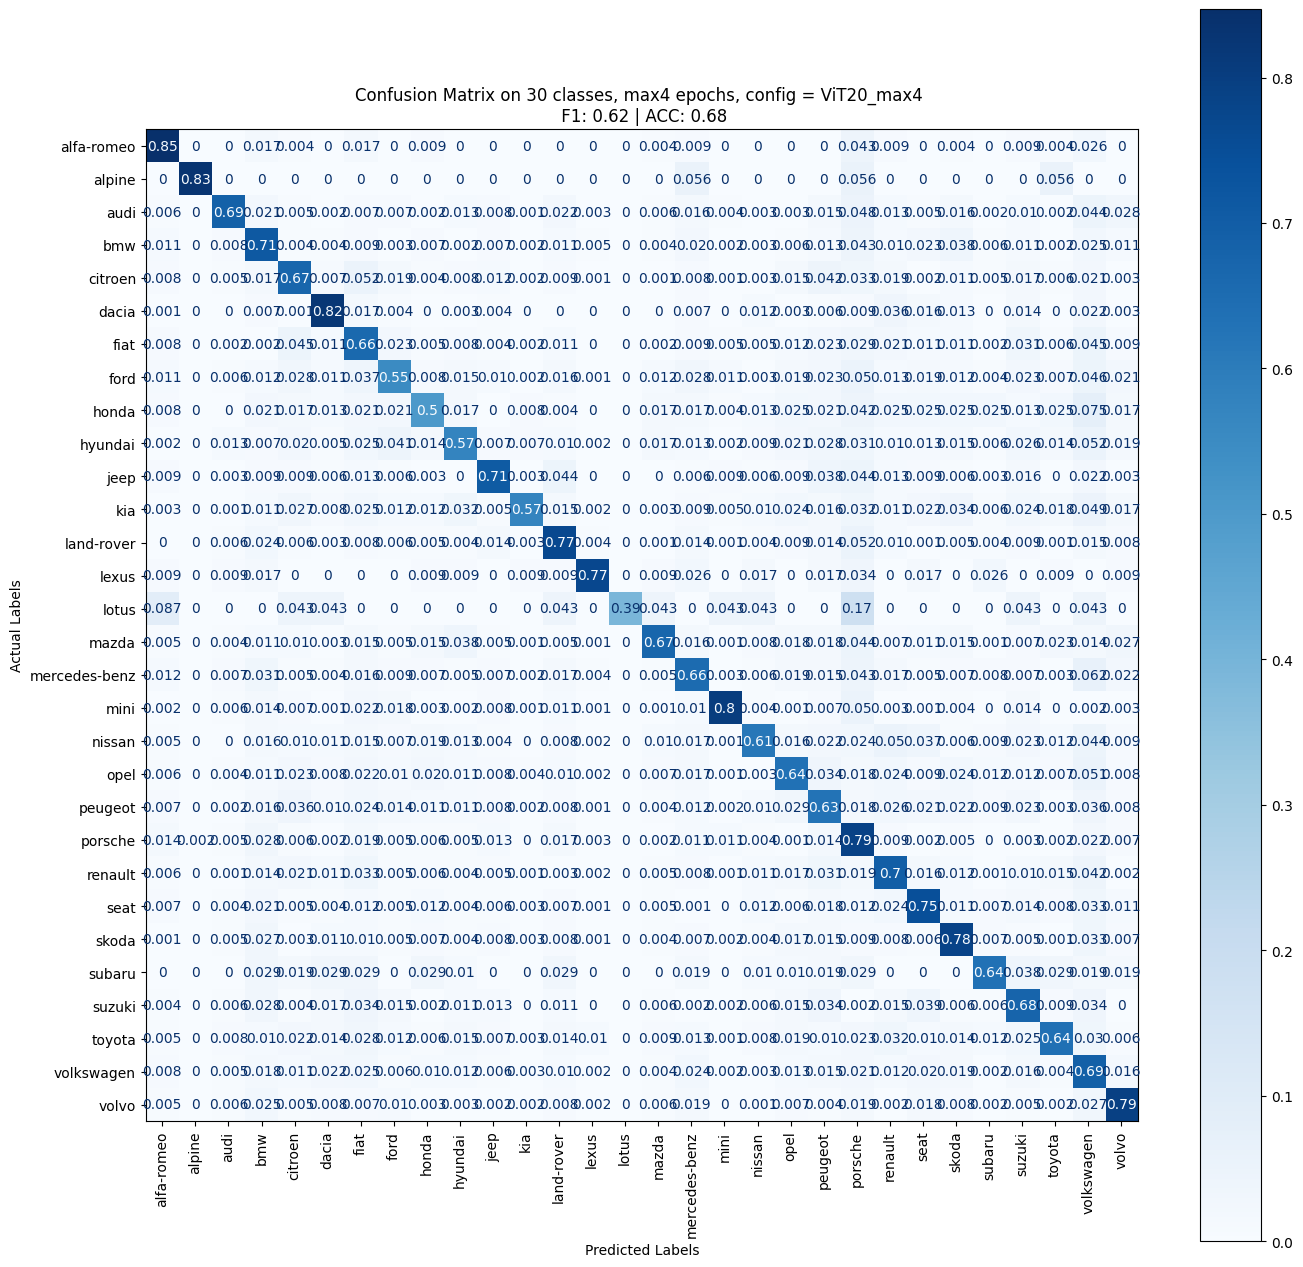

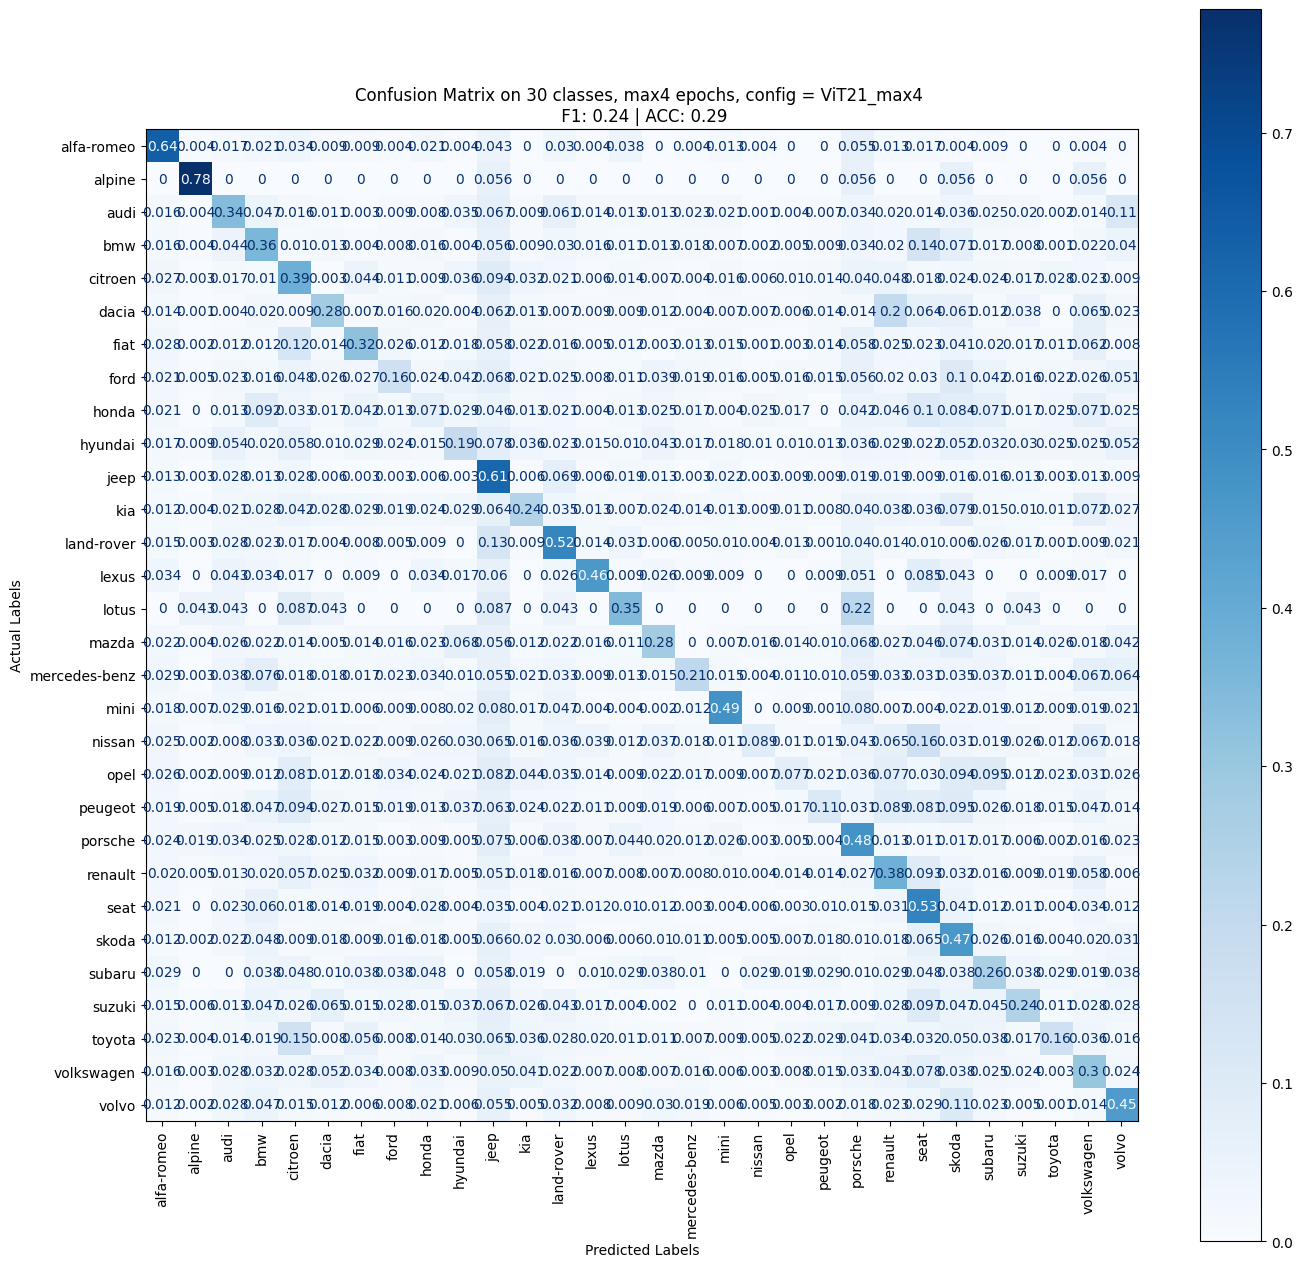

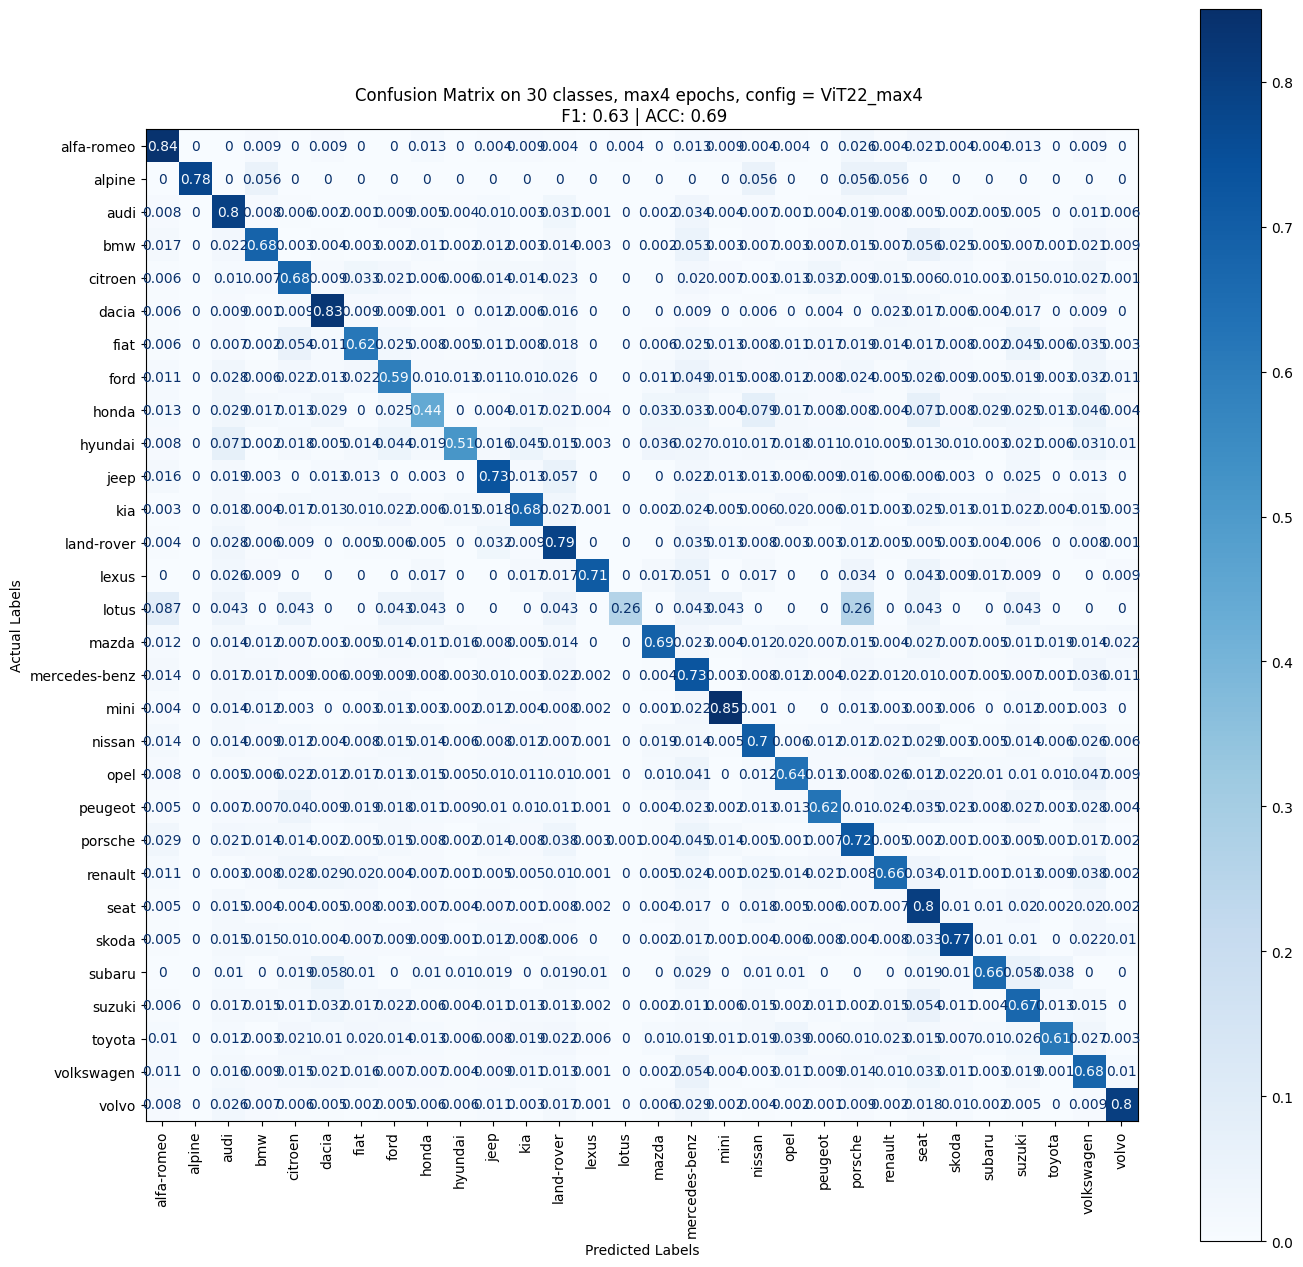

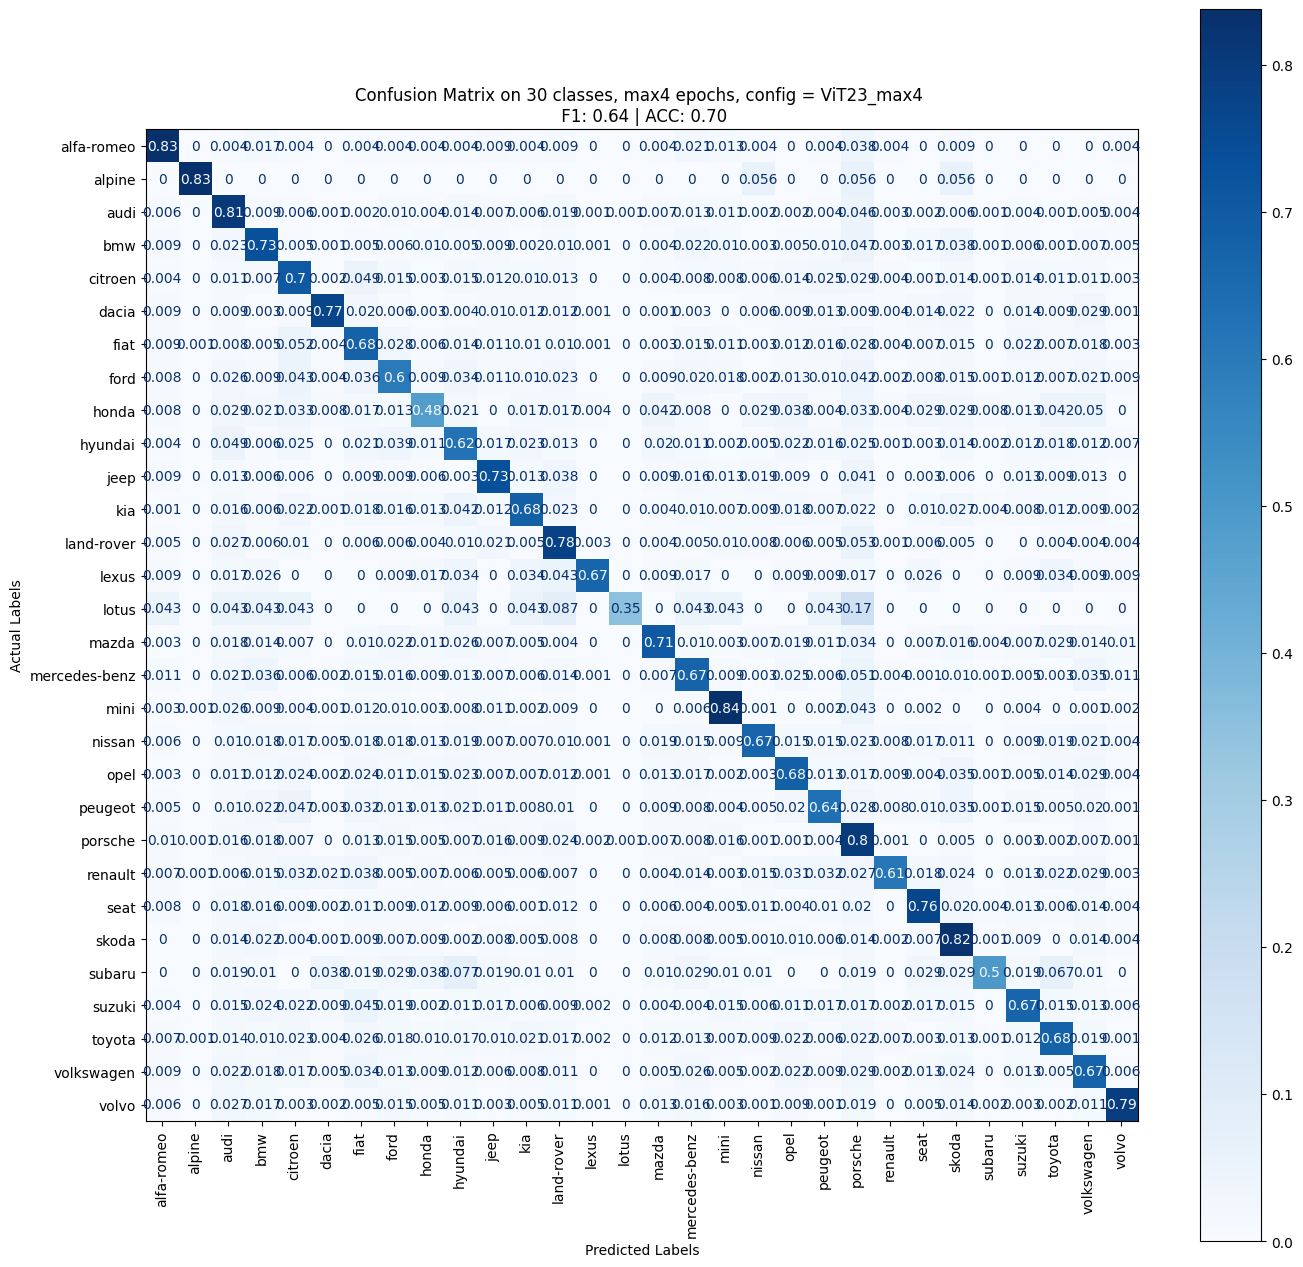

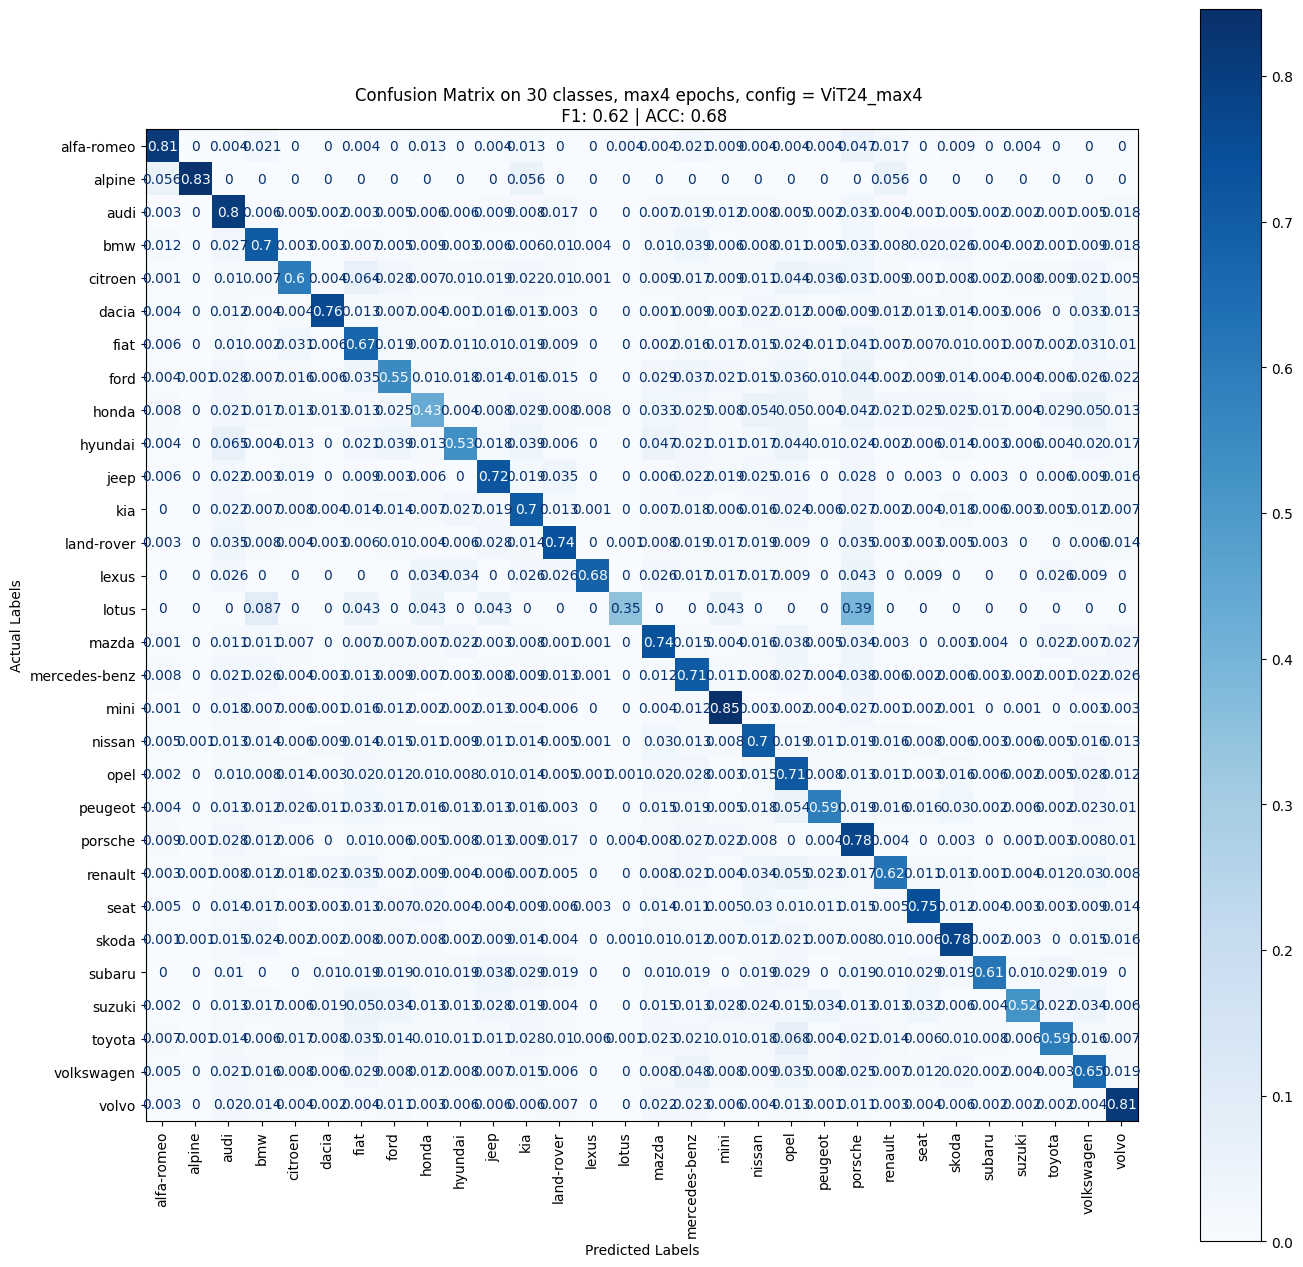

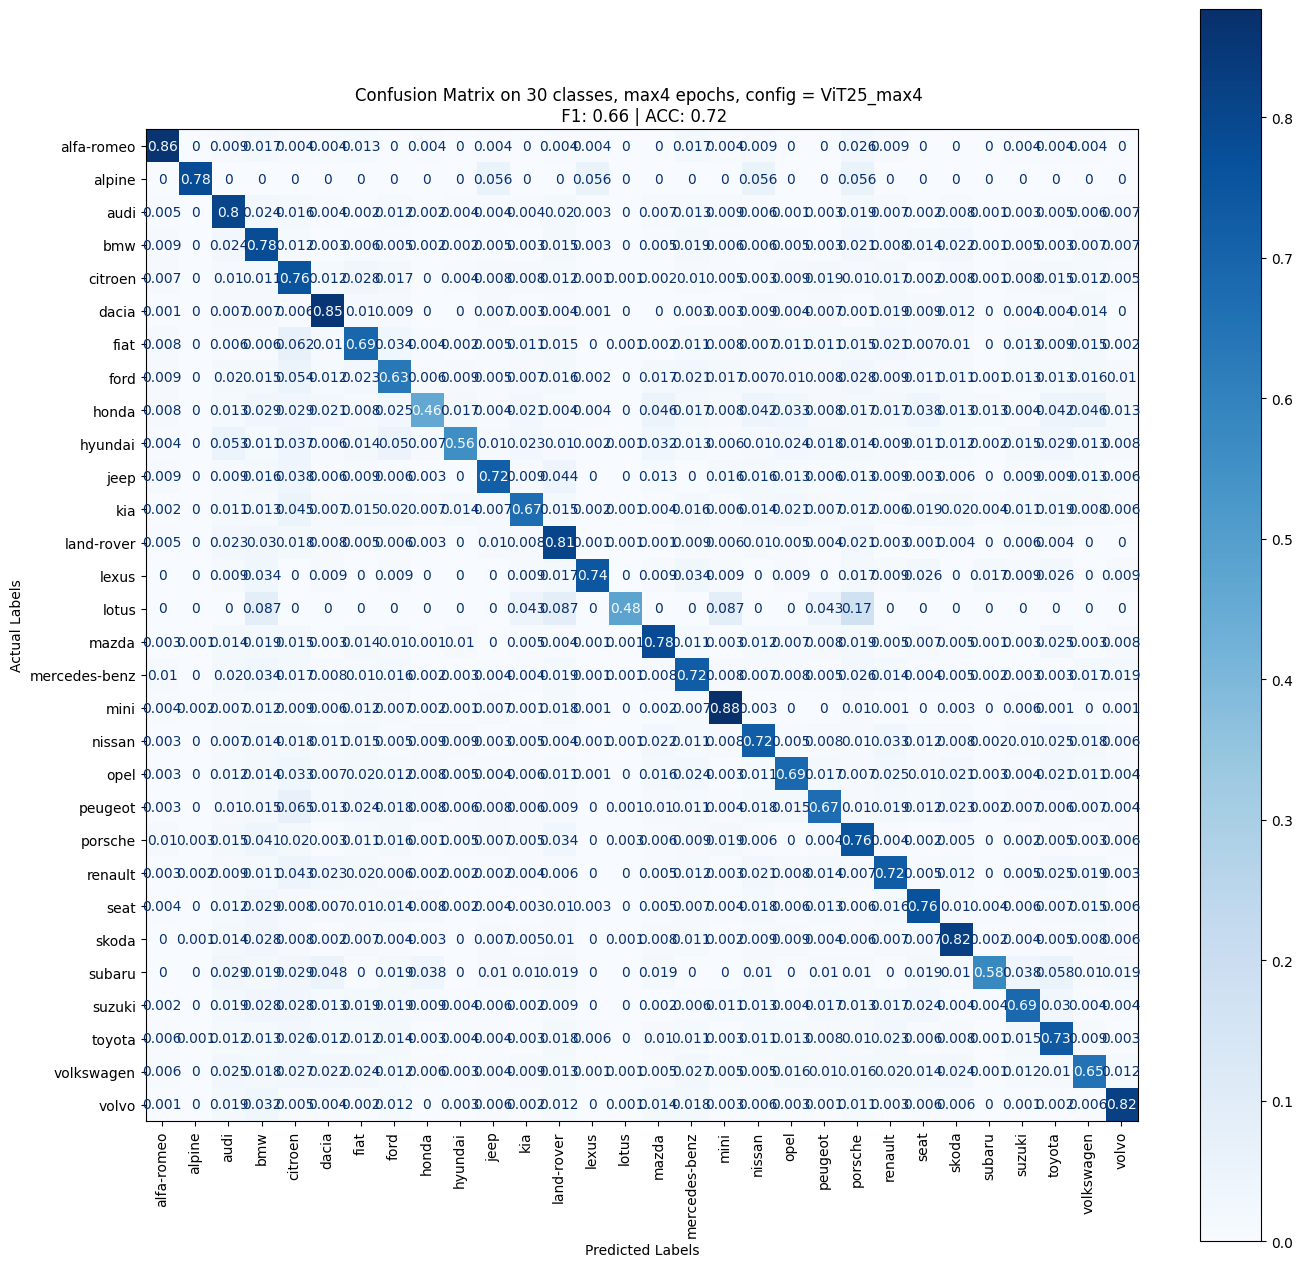

In [12]:
full_metrics = {}
for k in all_vit30_results:
    name = k
    pred = np.argmax(all_vit30_results[k], axis=1)
    act = all_vit30_actuals[k]['data']
    label_encoder = all_vit30_actuals[k]['encoder']
    metrics = implot.quick_metrics(act, pred)
    full_metrics[k] = metrics
    disp = implot.make_cm(act, pred, label_encoder.classes_)
    disp.title(f'Confusion Matrix on 30 classes, max4 epochs, config = {name} \n F1: {metrics["Macro F1 Score"]:.2f} | ACC: {metrics["Accuracy"]:.2f}')
    disp.show()

In [13]:
full_metrics

{'ViT17_max4': {'Accuracy': 0.6327854049949722,
  'Macro F1 Score': 0.5773703562382296,
  'Weighted F1 Score': 0.6584706321142594,
  "Cohen's Kappa": 0.6124769747123069},
 'ViT18_max4': {'Accuracy': 0.6190769357056373,
  'Macro F1 Score': 0.572408350584679,
  'Weighted F1 Score': 0.6292243754335555,
  "Cohen's Kappa": 0.596968679346721},
 'ViT19_max4': {'Accuracy': 0.6735209013113341,
  'Macro F1 Score': 0.6197288314667454,
  'Weighted F1 Score': 0.6821152756140895,
  "Cohen's Kappa": 0.6532902921745627},
 'ViT20_max4': {'Accuracy': 0.675552545711999,
  'Macro F1 Score': 0.6247340355155144,
  'Weighted F1 Score': 0.685480775008337,
  "Cohen's Kappa": 0.6555912883306261},
 'ViT21_max4': {'Accuracy': 0.2860924706027212,
  'Macro F1 Score': 0.23630341760656481,
  'Weighted F1 Score': 0.29796458966176914,
  "Cohen's Kappa": 0.2553814870093857},
 'ViT22_max4': {'Accuracy': 0.6904923146381006,
  'Macro F1 Score': 0.6277991388034335,
  'Weighted F1 Score': 0.7000735966846623,
  "Cohen's Kappa

/tmp/ipykernel_12645/2420455650.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha='right')
/tmp/ipykernel_12645/2420455650.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha='right')
/tmp/ipykernel_12645/2420455650.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha='right')
/tmp/ipykernel_12645/2420455650.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha='right')


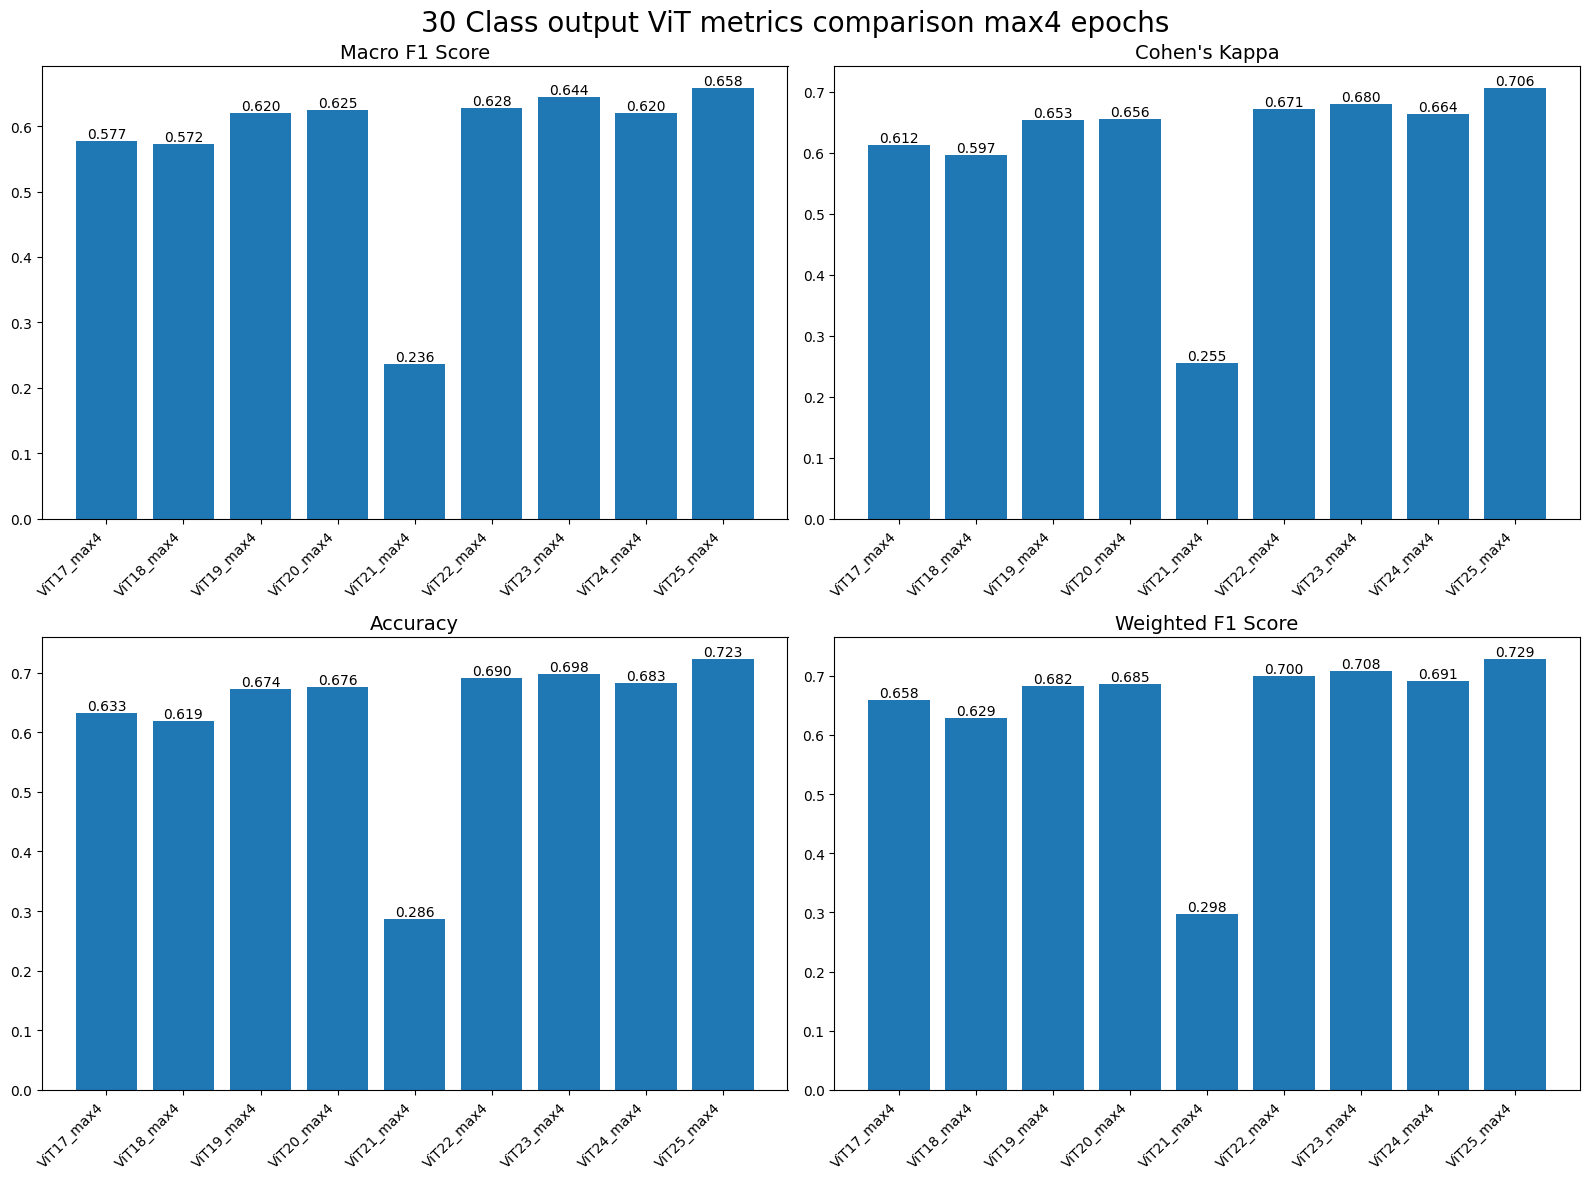

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics_to_plot = ["Macro F1 Score", "Cohen's Kappa", "Accuracy", "Weighted F1 Score"]
x_labels = list(full_metrics.keys())

for i, metric in enumerate(metrics_to_plot):
    values = [full_metrics[k][metric] for k in x_labels]
    ax = axes[i]
    bars = ax.bar(x_labels, values)
    ax.set_title(metric, fontsize=14)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')

    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}', ha='center', va='bottom', fontsize=10)
plt.suptitle('30 Class output ViT metrics comparison max4 epochs', fontsize=20)
plt.tight_layout()
plt.show()

NameError: name 'view_by_angle_test' is not defined

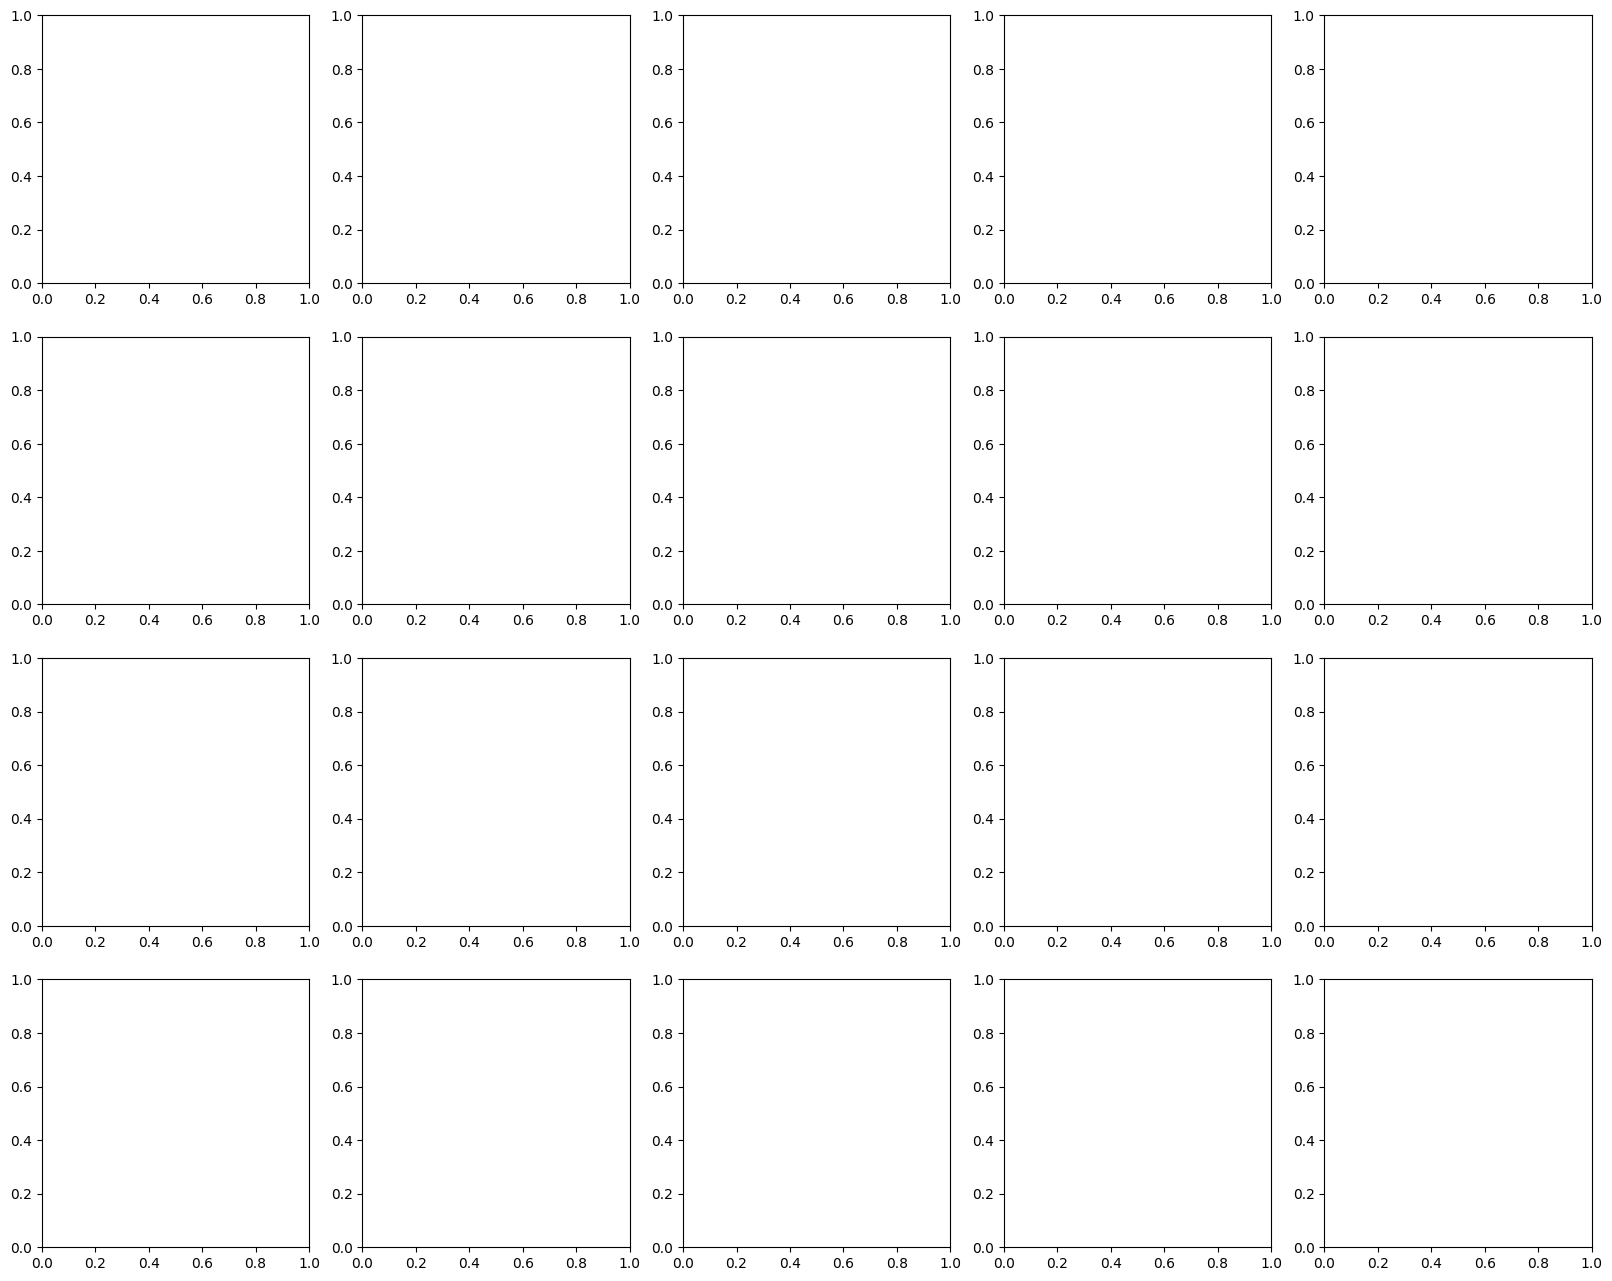

In [15]:
## TODO ## BUG ## URGENT 
# This codeblock needs to be re-implmeented for evaluating TINYVIT!!!

fig, axes = plt.subplots(4, 5, figsize=(20, 16))  # Adjust size as needed
axes = axes.flatten()  # Flatten to iterate easily

actual_labels = view_by_angle_test.y_encoded

for i, (vitname, predictions) in enumerate(all_vit_results.items()):
    if i >= 20:
        break

    prediction_labels = np.argmax(predictions, axis=1)
    metrics = implot.quick_metrics(actual_labels, prediction_labels)

    disp = implot.make_cm(actual_labels, prediction_labels, label_encoder.classes_, embed=True)
    ax = axes[i]
    disp.plot(ax=ax, cmap='Blues', colorbar=False)

    ax.set_title(f'{vitname}\nF1: {metrics["Macro F1 Score"]:.2f} | ACC: {metrics["Accuracy"]:.2f}', fontsize=10)
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("Actual Labels")
    ax.tick_params(axis='x', rotation=90)


plt.suptitle('TINY ViT comparison', fontsize=30)
plt.tight_layout()
plt.show()